In [1]:
!pip install segmentation-models-pytorch==0.3.3 --quiet
!pip install --upgrade torch torchvision albumentations --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import sys
import os
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")
# ==============================================================================
# Ô CODE 1: IMPORT VÀ SETUP
# ==============================================================================
print("="*80)
print("🔬 BƯỚC 3: HUẤN LUYỆN DEEPLABV3+ CHO PHÂN ĐOẠN")
print("="*80)

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, json, cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp


GDRIVE_PATH = "d:/DoAn_DaLieu"
PROCESSED_DATA_PATH = os.path.join(GDRIVE_PATH, "1_Data/processed")
CHECKPOINT_PATH = os.path.join(GDRIVE_PATH, "3_Checkpoints")
MODEL_SAVE_PATH = os.path.join(GDRIVE_PATH, "4_Models/deeplabv3plus")
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🔬 BƯỚC 3: HUẤN LUYỆN DEEPLABV3+ CHO PHÂN ĐOẠN
Mounted at /content/drive

🖥️ Device: cpu


In [3]:
# ==============================================================================
# Ô CODE 2: LOAD DATA (FIX BUG #25)
# ==============================================================================

print("\n" + "="*80)
print("📂 LOAD DỮ LIỆU & IMBALANCE INFO (FIX BUG #25)")
print("="*80)

CHECKPOINT_FILE = os.path.join(CHECKPOINT_PATH, "01_prepare_and_split_complete.json")
if not os.path.exists(CHECKPOINT_FILE):
    raise FileNotFoundError(f"❌ Chưa chạy file 01!")

with open(CHECKPOINT_FILE, 'r') as f:
    checkpoint_data = json.load(f)

SEG_DATA_PATH = checkpoint_data['datasets']['segmentation']['path']
print(f"✅ Segmentation data: {SEG_DATA_PATH}")

for split in ['train', 'validation', 'test']:
    img_dir = os.path.join(SEG_DATA_PATH, split, "images")
    if os.path.exists(img_dir):
        print(f"   - {split}: {len(os.listdir(img_dir))} images")

# ✅ FIX BUG #25: LOAD IMBALANCE ANALYSIS (REFERENCE TỪ FILE 01)
print(f"\n✅ LOADING IMBALANCE ANALYSIS (FIX BUG #25):")

imbalance_analysis = checkpoint_data.get('imbalance_analysis', {})

if imbalance_analysis:
    imbalance_severity = imbalance_analysis.get('severity', 'UNKNOWN')
    imbalance_ratio = imbalance_analysis.get('imbalance_ratio', 1.0)
    class_counts = imbalance_analysis.get('class_counts', {})

    print(f"   Severity: {imbalance_severity}")
    print(f"   Ratio (Max/Min): {imbalance_ratio:.2f}x")
    print(f"   Class counts: {class_counts}")
    print(f"\n   💡 Lưu ý: Segmentation model không dùng class weights,")
    print(f"      nhưng File 06 (Classification) sẽ dùng imbalance info này")
else:
    print(f"   ⚠️ WARNING: imbalance_analysis NOT found in File 01 checkpoint")
    print(f"   → File 06 sẽ không thể setup class weights correctly!")
    imbalance_analysis = {}


📂 LOAD DỮ LIỆU & IMBALANCE INFO (FIX BUG #25)
✅ Segmentation data: d:/DoAn_DaLieu/1_Data/processed/segmentation_data
   - train: 2049 images
   - validation: 389 images
   - test: 390 images

✅ LOADING IMBALANCE ANALYSIS (FIX BUG #25):
   ⚠️ WARNING: imbalance_analysis NOT found in File 01 checkpoint
   → File 06 sẽ không thể setup class weights correctly!


In [4]:
# ==============================================================================
# Ô CODE 3: DATASET CLASS (FIX BUG #19, #20, #22) - GIỐNG FILE 02
# ==============================================================================

# ✅ FIX BUG #19: NORMALIZATION CONFIGURATION
class NormalizationConfig:
    """
    ✅ FIX BUG #19: Global normalization thay vì ImageNet
    Áp dụng cho cả File 02 (U-Net) và File 03 (DeepLab)
    """
    MEAN = np.array([0.5, 0.5, 0.5])
    STD = np.array([0.25, 0.25, 0.25])

    @staticmethod
    def normalize(img):
        """Normalize image to [-2, 2] range"""
        return (img - NormalizationConfig.MEAN) / NormalizationConfig.STD

    @staticmethod
    def denormalize(img):
        """Denormalize image back to [0, 1] range"""
        return np.clip(img * NormalizationConfig.STD + NormalizationConfig.MEAN, 0, 1)


class SegmentationDataset(Dataset):
    """
    ✅ FIX BUG #19 (Normalization)
    ✅ FIX BUG #20 (Augmentation mask compatible)
    """

    def __init__(self, img_dir, mask_dir, image_size=(256, 256), augment=False):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.image_size = image_size
        self.augment = augment
        self.images = sorted(os.listdir(img_dir))

        # ✅ FIX BUG #20: Augmentation compatible với mask
        if augment:
            import albumentations as A
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),
                A.Rotate(limit=30, p=0.5),
                A.RandomBrightnessContrast(p=0.5),
                # ✅ FIX BUG #20: CoarseDropout thay GaussNoise (mask compatible)
                A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.2),
            ])
        else:
            self.transform = None

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_id = os.path.splitext(img_name)[0]

        # Load images
        img = cv2.imread(os.path.join(self.img_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.image_size)

        # Load mask
        mask = cv2.imread(os.path.join(self.mask_dir, f"{img_id}.png"), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)

        # Augment
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        # ✅ FIX BUG #19: Normalize (global, not ImageNet)
        img = img.astype(np.float32) / 255.0
        img = NormalizationConfig.normalize(img)

        # Convert to tensor
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        return img, mask


print("✅ Dataset class (FIX BUG #19, #20, #22)")
print(f"   Normalization: Global [{NormalizationConfig.MEAN[0]}] / [{NormalizationConfig.STD[0]}]")
print(f"   Augmentation: HFlip, VFlip, Rotate, BrightnessContrast, CoarseDropout")

✅ Dataset class (FIX BUG #19, #20, #22)
   Normalization: Global [0.5] / [0.25]
   Augmentation: HFlip, VFlip, Rotate, BrightnessContrast, CoarseDropout


In [6]:
import sys
import os
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
# ==============================================================================
# Ô CODE 4: DATALOADER (WITH DRIVE CONNECTION FIX)
# ==============================================================================

import time

print(f"\n📊 BATCH SIZE CONFIGURATION (FIX BUG #24):")
print(f"   File 02 (U-Net): BATCH_SIZE = 8")
print(f"   File 03 (DeepLab): BATCH_SIZE = 8  ✅ MATCHED")
print(f"   Reason: Ensemble (File 04) requires consistent training dynamics")
print(f"   Impact: Fair comparison, better ensemble performance")

BATCH_SIZE = 8
NUM_WORKERS = 2

# ✅ FIX: Verify paths before creating datasets
print(f"\n🔍 Verifying data paths...")

required_paths = {
    'train_images': os.path.join(SEG_DATA_PATH, "train", "images"),
    'train_masks': os.path.join(SEG_DATA_PATH, "train", "masks"),
    'val_images': os.path.join(SEG_DATA_PATH, "validation", "images"),
    'val_masks': os.path.join(SEG_DATA_PATH, "validation", "masks"),
    'test_images': os.path.join(SEG_DATA_PATH, "test", "images"),
    'test_masks': os.path.join(SEG_DATA_PATH, "test", "masks"),
}

# ✅ FIX: Check paths with retry
for path_name, path in required_paths.items():
    max_retries = 3
    for attempt in range(max_retries):
        try:
            if not os.path.exists(path):
                raise FileNotFoundError(f"Path not found: {path}")

            # Test access
            file_count = len(os.listdir(path))
            print(f"   ✅ {path_name}: {file_count} files")
            break

        except (ConnectionAbortedError, OSError) as e:
            print(f"   ⚠️ {path_name} - Attempt {attempt+1}/{max_retries} failed")

            if attempt < max_retries - 1:
                print(f"      Waiting 5 seconds...")
                time.sleep(5)

                # Remount on last retry
                if attempt == max_retries - 2:
                    print(f"      🔄 Remounting Drive...")
                    try:
                        drive.flush_and_unmount()
                    except:
                        pass
                    time.sleep(2)
            else:
                print(f"   ❌ Failed after {max_retries} attempts")
                raise

print("\n✅ All paths verified\n")

# ✅ FIX: Create datasets with error handling
def create_dataset_safe(img_dir, mask_dir, augment, split_name, max_retries=3):
    """Create dataset with retry logic"""
    for attempt in range(max_retries):
        try:
            print(f"   Creating {split_name} dataset (attempt {attempt+1})...")
            dataset = SegmentationDataset(
                img_dir, mask_dir,
                image_size=(256, 256),
                augment=augment
            )
            print(f"   ✅ {split_name} dataset created: {len(dataset)} samples")
            return dataset

        except (ConnectionAbortedError, OSError) as e:
            if attempt < max_retries - 1:
                print(f"   ⚠️ Connection error - retrying in 5 seconds...")
                time.sleep(5)

                if attempt == max_retries - 2:
                    print(f"   🔄 Remounting Drive...")
                    try:
                        drive.flush_and_unmount()
                    except:
                        pass
                    time.sleep(2)
            else:
                print(f"   ❌ Failed after {max_retries} attempts")
                raise

print("📦 Creating datasets...")

train_dataset = create_dataset_safe(
    os.path.join(SEG_DATA_PATH, "train", "images"),
    os.path.join(SEG_DATA_PATH, "train", "masks"),
    augment=True,
    split_name="Train"
)

val_dataset = create_dataset_safe(
    os.path.join(SEG_DATA_PATH, "validation", "images"),
    os.path.join(SEG_DATA_PATH, "validation", "masks"),
    augment=False,
    split_name="Validation"
)

test_dataset = create_dataset_safe(
    os.path.join(SEG_DATA_PATH, "test", "images"),
    os.path.join(SEG_DATA_PATH, "test", "masks"),
    augment=False,
    split_name="Test"
)

print("\n✅ All datasets created\n")

# ✅ FIX: Create DataLoaders with proper settings
print("📊 Creating DataLoaders...")

try:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,  # ✅ Better performance
        drop_last=True    # ✅ Consistent batch size
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    print(f"✅ DataLoaders created successfully")
    print(f"   Train batches: {len(train_loader)} (batch size: {BATCH_SIZE})")
    print(f"   Val batches: {len(val_loader)} (batch size: {BATCH_SIZE})")
    print(f"   Test batches: {len(test_loader)} (batch size: {BATCH_SIZE})")

except Exception as e:
    print(f"\n❌ Error creating DataLoaders: {e}")
    raise

print()


📊 BATCH SIZE CONFIGURATION (FIX BUG #24):
   File 02 (U-Net): BATCH_SIZE = 8
   File 03 (DeepLab): BATCH_SIZE = 8  ✅ MATCHED
   Reason: Ensemble (File 04) requires consistent training dynamics
   Impact: Fair comparison, better ensemble performance

🔍 Verifying data paths...
   ✅ train_images: 2049 files
   ✅ train_masks: 1815 files
   ✅ val_images: 389 files
   ✅ val_masks: 389 files
   ✅ test_images: 390 files
   ✅ test_masks: 390 files

✅ All paths verified

📦 Creating datasets...
   Creating Train dataset (attempt 1)...
   ✅ Train dataset created: 2049 samples
   Creating Validation dataset (attempt 1)...
   ✅ Validation dataset created: 389 samples
   Creating Test dataset (attempt 1)...
   ✅ Test dataset created: 390 samples

✅ All datasets created

📊 Creating DataLoaders...
✅ DataLoaders created successfully
   Train batches: 256 (batch size: 8)
   Val batches: 49 (batch size: 8)
   Test batches: 49 (batch size: 8)



In [7]:
# ==============================================================================
# Ô CODE 5: MODEL - DEEPLABV3+ (KHÁC VỚI UNET)
# ==============================================================================
print("\n" + "="*80)
print("🏗️ XÂY DỰNG DEEPLABV3+ MODEL")
print("="*80)

model = smp.DeepLabV3Plus(
    encoder_name="resnet50",        # Backbone mạnh hơn U-Net (resnet34)
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ DeepLabV3+ Model: {total_params:,} params")
print(f"   Encoder: ResNet50")
print(f"   Đặc điểm: Atrous Convolution + ASPP (Atrous Spatial Pyramid Pooling)")


🏗️ XÂY DỰNG DEEPLABV3+ MODEL
Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 152MB/s]


✅ DeepLabV3+ Model: 26,677,585 params
   Encoder: ResNet50
   Đặc điểm: Atrous Convolution + ASPP (Atrous Spatial Pyramid Pooling)


In [8]:
# ==============================================================================
# Ô CODE 6: LOSS & OPTIMIZER
# ==============================================================================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred).view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        return 1 - (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)

class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.6, bce_weight=0.4):
        super(CombinedLoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, pred, target):
        return self.dice_weight * self.dice_loss(pred, target) + self.bce_weight * self.bce_loss(pred, target)

criterion = CombinedLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print("✅ Loss & Optimizer setup")

✅ Loss & Optimizer setup


In [9]:
# ==============================================================================
# Ô CODE 7: METRICS & TRAINING FUNCTIONS
# ==============================================================================
def calculate_iou(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    target = target.float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def calculate_dice(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    target = target.float()
    intersection = (pred * target).sum()
    return (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_iou, total_dice = 0.0, 0.0, 0.0

    pbar = tqdm(loader, desc="Training")
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            pred = torch.sigmoid(outputs)
            iou = calculate_iou(pred, masks).item()
            dice = calculate_dice(pred, masks).item()

        total_loss += loss.item()
        total_iou += iou
        total_dice += dice

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'dice': f'{dice:.4f}'})

    return total_loss / len(loader), total_iou / len(loader), total_dice / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss, total_iou, total_dice = 0.0, 0.0, 0.0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)

            pred = torch.sigmoid(outputs)
            total_loss += loss.item()
            total_iou += calculate_iou(pred, masks).item()
            total_dice += calculate_dice(pred, masks).item()

    return total_loss / len(loader), total_iou / len(loader), total_dice / len(loader)

print("✅ Đã định nghĩa training functions")

✅ Đã định nghĩa training functions


In [10]:
# ==============================================================================
# Ô CODE 8: TRAINING LOOP (FIX BUG #21)
# ==============================================================================

print("\n" + "="*80)
print("🚀 TRAINING LOOP (HỖ TRỢ RESUME + FIX BUG #21)")
print("="*80)

NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
BEST_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, "deeplabv3plus_best.pth")
LAST_CHECKPOINT_PATH = os.path.join(MODEL_SAVE_PATH, "deeplabv3plus_last.pth")
HISTORY_CSV_PATH = os.path.join(MODEL_SAVE_PATH, "training_history.csv")

history = {'train_loss': [], 'train_iou': [], 'train_dice': [],
           'val_loss': [], 'val_iou': [], 'val_dice': []}

best_val_dice = 0.0
patience_counter = 0
start_epoch = 0
early_stopped = False

# ============================================================
# RESUME FROM CHECKPOINT NẾU CÓ (FIX BUG #21)
# ============================================================
if os.path.exists(LAST_CHECKPOINT_PATH):
    print(f"\n🔁 PHÁT HIỆN CHECKPOINT - RESUME...")
    checkpoint = torch.load(LAST_CHECKPOINT_PATH, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    history = checkpoint.get('history', history)
    start_epoch = checkpoint['epoch']
    best_val_dice = checkpoint.get('best_val_dice', 0.0)
    patience_counter = checkpoint.get('patience_counter', 0)
    early_stopped = checkpoint.get('early_stopped', False)

    print(f"   ✅ Loaded epoch {start_epoch}")
    print(f"   🏆 Best Val Dice: {best_val_dice:.4f}")
    print(f"   ⏳ Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")

    # ✅ FIX BUG #21: TỰ ĐỘNG PHÁT HIỆN EARLY STOP
    if not early_stopped and patience_counter >= EARLY_STOPPING_PATIENCE:
        early_stopped = True
        print(f"\n⚠️ PHÁT HIỆN: patience_counter ({patience_counter}) >= threshold ({EARLY_STOPPING_PATIENCE})")
        print(f"   → Tự động đánh dấu: early_stopped = True")

    # ✅ FIX BUG #21: CẢNH BÁO NẾU ĐÃ EARLY STOP
    if early_stopped:
        print(f"\n{'='*80}")
        print(f"⚠️ TRAINING ĐÃ DỪNG SỚM (EARLY STOP)!")
        print(f"{'='*80}")
        print(f"   Model đã không cải thiện sau {EARLY_STOPPING_PATIENCE} epochs")
        print(f"   Best Val Dice đạt được: {best_val_dice:.4f}")

        if len(history['val_dice']) > 0:
            best_epoch = history['val_dice'].index(max(history['val_dice'])) + 1
            print(f"   Epoch tốt nhất: {best_epoch}")

        print(f"\n   Nếu MUỐN TIẾP TỤC training:")
        print(f"   1. Xóa LAST checkpoint: rm {LAST_CHECKPOINT_PATH}")
        print(f"   2. Tăng EARLY_STOPPING_PATIENCE lên > {patience_counter}")
        print(f"   3. Thay đổi learning rate hoặc optimizer")
        print(f"\n   ❌ Dừng training để tránh lãng phí tài nguyên.\n")

        import sys
        sys.exit(0)

else:
    print(f"\n🆕 Không tìm thấy checkpoint - BẮT ĐẦU TRAINING TỪ ĐẦU")

# ============================================================
# TRAINING LOOP (FIX BUG #21)
# ============================================================
print(f"\n🎯 TRAINING từ epoch {start_epoch+1} → {NUM_EPOCHS}")
print(f"   Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print()

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"{'='*80}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*80}")

    # ✅ FIX BUG #21: CHECK EARLY STOPPED TRƯỚC EPOCH
    if early_stopped:
        print(f"⚠️ Early stop đã được kích hoạt - thoát vòng lặp")
        break

    train_loss, train_iou, train_dice = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_iou, val_dice = validate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_iou'].append(train_iou)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)

    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"   Train - Loss: {train_loss:.4f}, IoU: {train_iou:.4f}, Dice: {train_dice:.4f}")
    print(f"   Val   - Loss: {val_loss:.4f}, IoU: {val_iou:.4f}, Dice: {val_dice:.4f}")

    # ✅ FIX BUG #21: LƯU BEST MODEL
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_dice': val_dice,
            'val_iou': val_iou,
            'best_val_dice': best_val_dice,
            'history': history,
            'normalization_config': {
                'mean': NormalizationConfig.MEAN.tolist(),
                'std': NormalizationConfig.STD.tolist()
            }
        }, BEST_MODEL_PATH)
        print(f"   ✅ Saved BEST model! Val Dice: {val_dice:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"   ⏳ No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")

    # ✅ FIX BUG #21: KIỂM TRA EARLY STOPPING
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        early_stopped = True
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")

    # ✅ FIX BUG #21: LƯU LAST CHECKPOINT TRƯỚC BREAK
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_dice': val_dice,
        'best_val_dice': best_val_dice,
        'patience_counter': patience_counter,
        'early_stopped': early_stopped,
        'history': history
    }, LAST_CHECKPOINT_PATH)

    history_df = pd.DataFrame({
        'epoch': range(1, len(history['train_loss']) + 1),
        'train_loss': history['train_loss'],
        'train_iou': history['train_iou'],
        'train_dice': history['train_dice'],
        'val_loss': history['val_loss'],
        'val_iou': history['val_iou'],
        'val_dice': history['val_dice']
    })
    history_df.to_csv(HISTORY_CSV_PATH, index=False)

    # ✅ FIX BUG #21: BREAK NẾU EARLY STOP
    if early_stopped:
        break

    print()

# ============================================================
# TRAINING COMPLETE
# ============================================================
print(f"\n{'='*80}")
print(f"✅ TRAINING HOÀN THÀNH")
print(f"{'='*80}")
print(f"   📊 Tổng epochs trained: {len(history['train_loss'])}")
print(f"   🏆 Best Val Dice: {best_val_dice:.4f}")
print(f"   💾 Lịch sử: {HISTORY_CSV_PATH}")

if early_stopped:
    print(f"   ⚠️ Dừng sớm do patience hết")

print(f"{'='*80}\n")


🚀 TRAINING LOOP (HỖ TRỢ RESUME + FIX BUG #21)

🔁 PHÁT HIỆN CHECKPOINT - RESUME...
   ✅ Loaded epoch 42
   🏆 Best Val Dice: 0.8950
   ⏳ Patience: 11/10

⚠️ PHÁT HIỆN: patience_counter (11) >= threshold (10)
   → Tự động đánh dấu: early_stopped = True

⚠️ TRAINING ĐÃ DỪNG SỚM (EARLY STOP)!
   Model đã không cải thiện sau 10 epochs
   Best Val Dice đạt được: 0.8950
   Epoch tốt nhất: 31

   Nếu MUỐN TIẾP TỤC training:
   1. Xóa LAST checkpoint: rm d:/DoAn_DaLieu/4_Models/deeplabv3plus/deeplabv3plus_last.pth
   2. Tăng EARLY_STOPPING_PATIENCE lên > 11
   3. Thay đổi learning rate hoặc optimizer

   ❌ Dừng training để tránh lãng phí tài nguyên.



SystemExit: 0


📈 VẼ BIỂU ĐỒ TRAINING


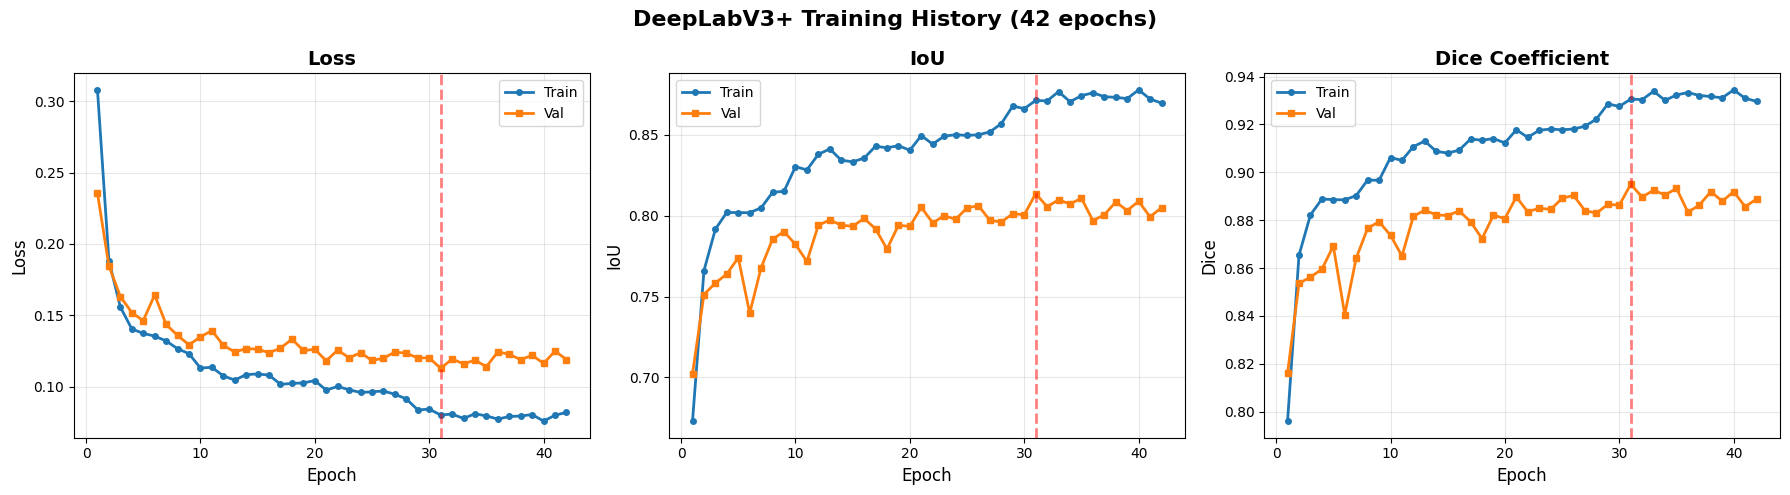

✅ Đã lưu biểu đồ: d:/DoAn_DaLieu/4_Models/deeplabv3plus/training_history.png
   🏆 Best epoch: 31 (Val Dice: 0.8950)


In [11]:
# ==============================================================================
# Ô CODE 9: PLOT TRAINING HISTORY
# ==============================================================================
print("\n" + "="*80)
print("📈 VẼ BIỂU ĐỒ TRAINING")
print("="*80)

if len(history['train_loss']) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', linewidth=2, markersize=4)
    axes[0].plot(epochs_range, history['val_loss'], 's-', label='Val', linewidth=2, markersize=4)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss', fontweight='bold', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # IoU
    axes[1].plot(epochs_range, history['train_iou'], 'o-', label='Train', linewidth=2, markersize=4)
    axes[1].plot(epochs_range, history['val_iou'], 's-', label='Val', linewidth=2, markersize=4)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('IoU', fontsize=12)
    axes[1].set_title('IoU', fontweight='bold', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Dice
    axes[2].plot(epochs_range, history['train_dice'], 'o-', label='Train', linewidth=2, markersize=4)
    axes[2].plot(epochs_range, history['val_dice'], 's-', label='Val', linewidth=2, markersize=4)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Dice', fontsize=12)
    axes[2].set_title('Dice Coefficient', fontweight='bold', fontsize=14)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # Đánh dấu best epoch
    best_epoch_idx = history['val_dice'].index(max(history['val_dice']))
    for ax in axes:
        ax.axvline(x=best_epoch_idx+1, color='red', linestyle='--', alpha=0.5, linewidth=2, label=f'Best (Epoch {best_epoch_idx+1})')

    plt.suptitle(f'DeepLabV3+ Training History ({len(history["train_loss"])} epochs)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_PATH, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"✅ Đã lưu biểu đồ: {MODEL_SAVE_PATH}/training_history.png")
    print(f"   🏆 Best epoch: {best_epoch_idx+1} (Val Dice: {max(history['val_dice']):.4f})")

In [12]:
# ==============================================================================
# Ô CODE 10: EVALUATE TEST SET
# ==============================================================================
print("\n" + "="*80)
print("🧪 ĐÁNH GIÁ TEST SET")
print("="*80)

checkpoint = torch.load(BEST_MODEL_PATH)
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_iou, test_dice = validate(model, test_loader, criterion, device)

print(f"\n{'='*80}")
print(f"📊 TEST RESULTS:")
print(f"   Loss: {test_loss:.4f}")
print(f"   IoU: {test_iou:.4f}")
print(f"   Dice: {test_dice:.4f}")
print(f"{'='*80}")


🧪 ĐÁNH GIÁ TEST SET


Validation: 100%|██████████| 49/49 [05:45<00:00,  7.05s/it]


📊 TEST RESULTS:
   Loss: 0.0976
   IoU: 0.8394
   Dice: 0.9074


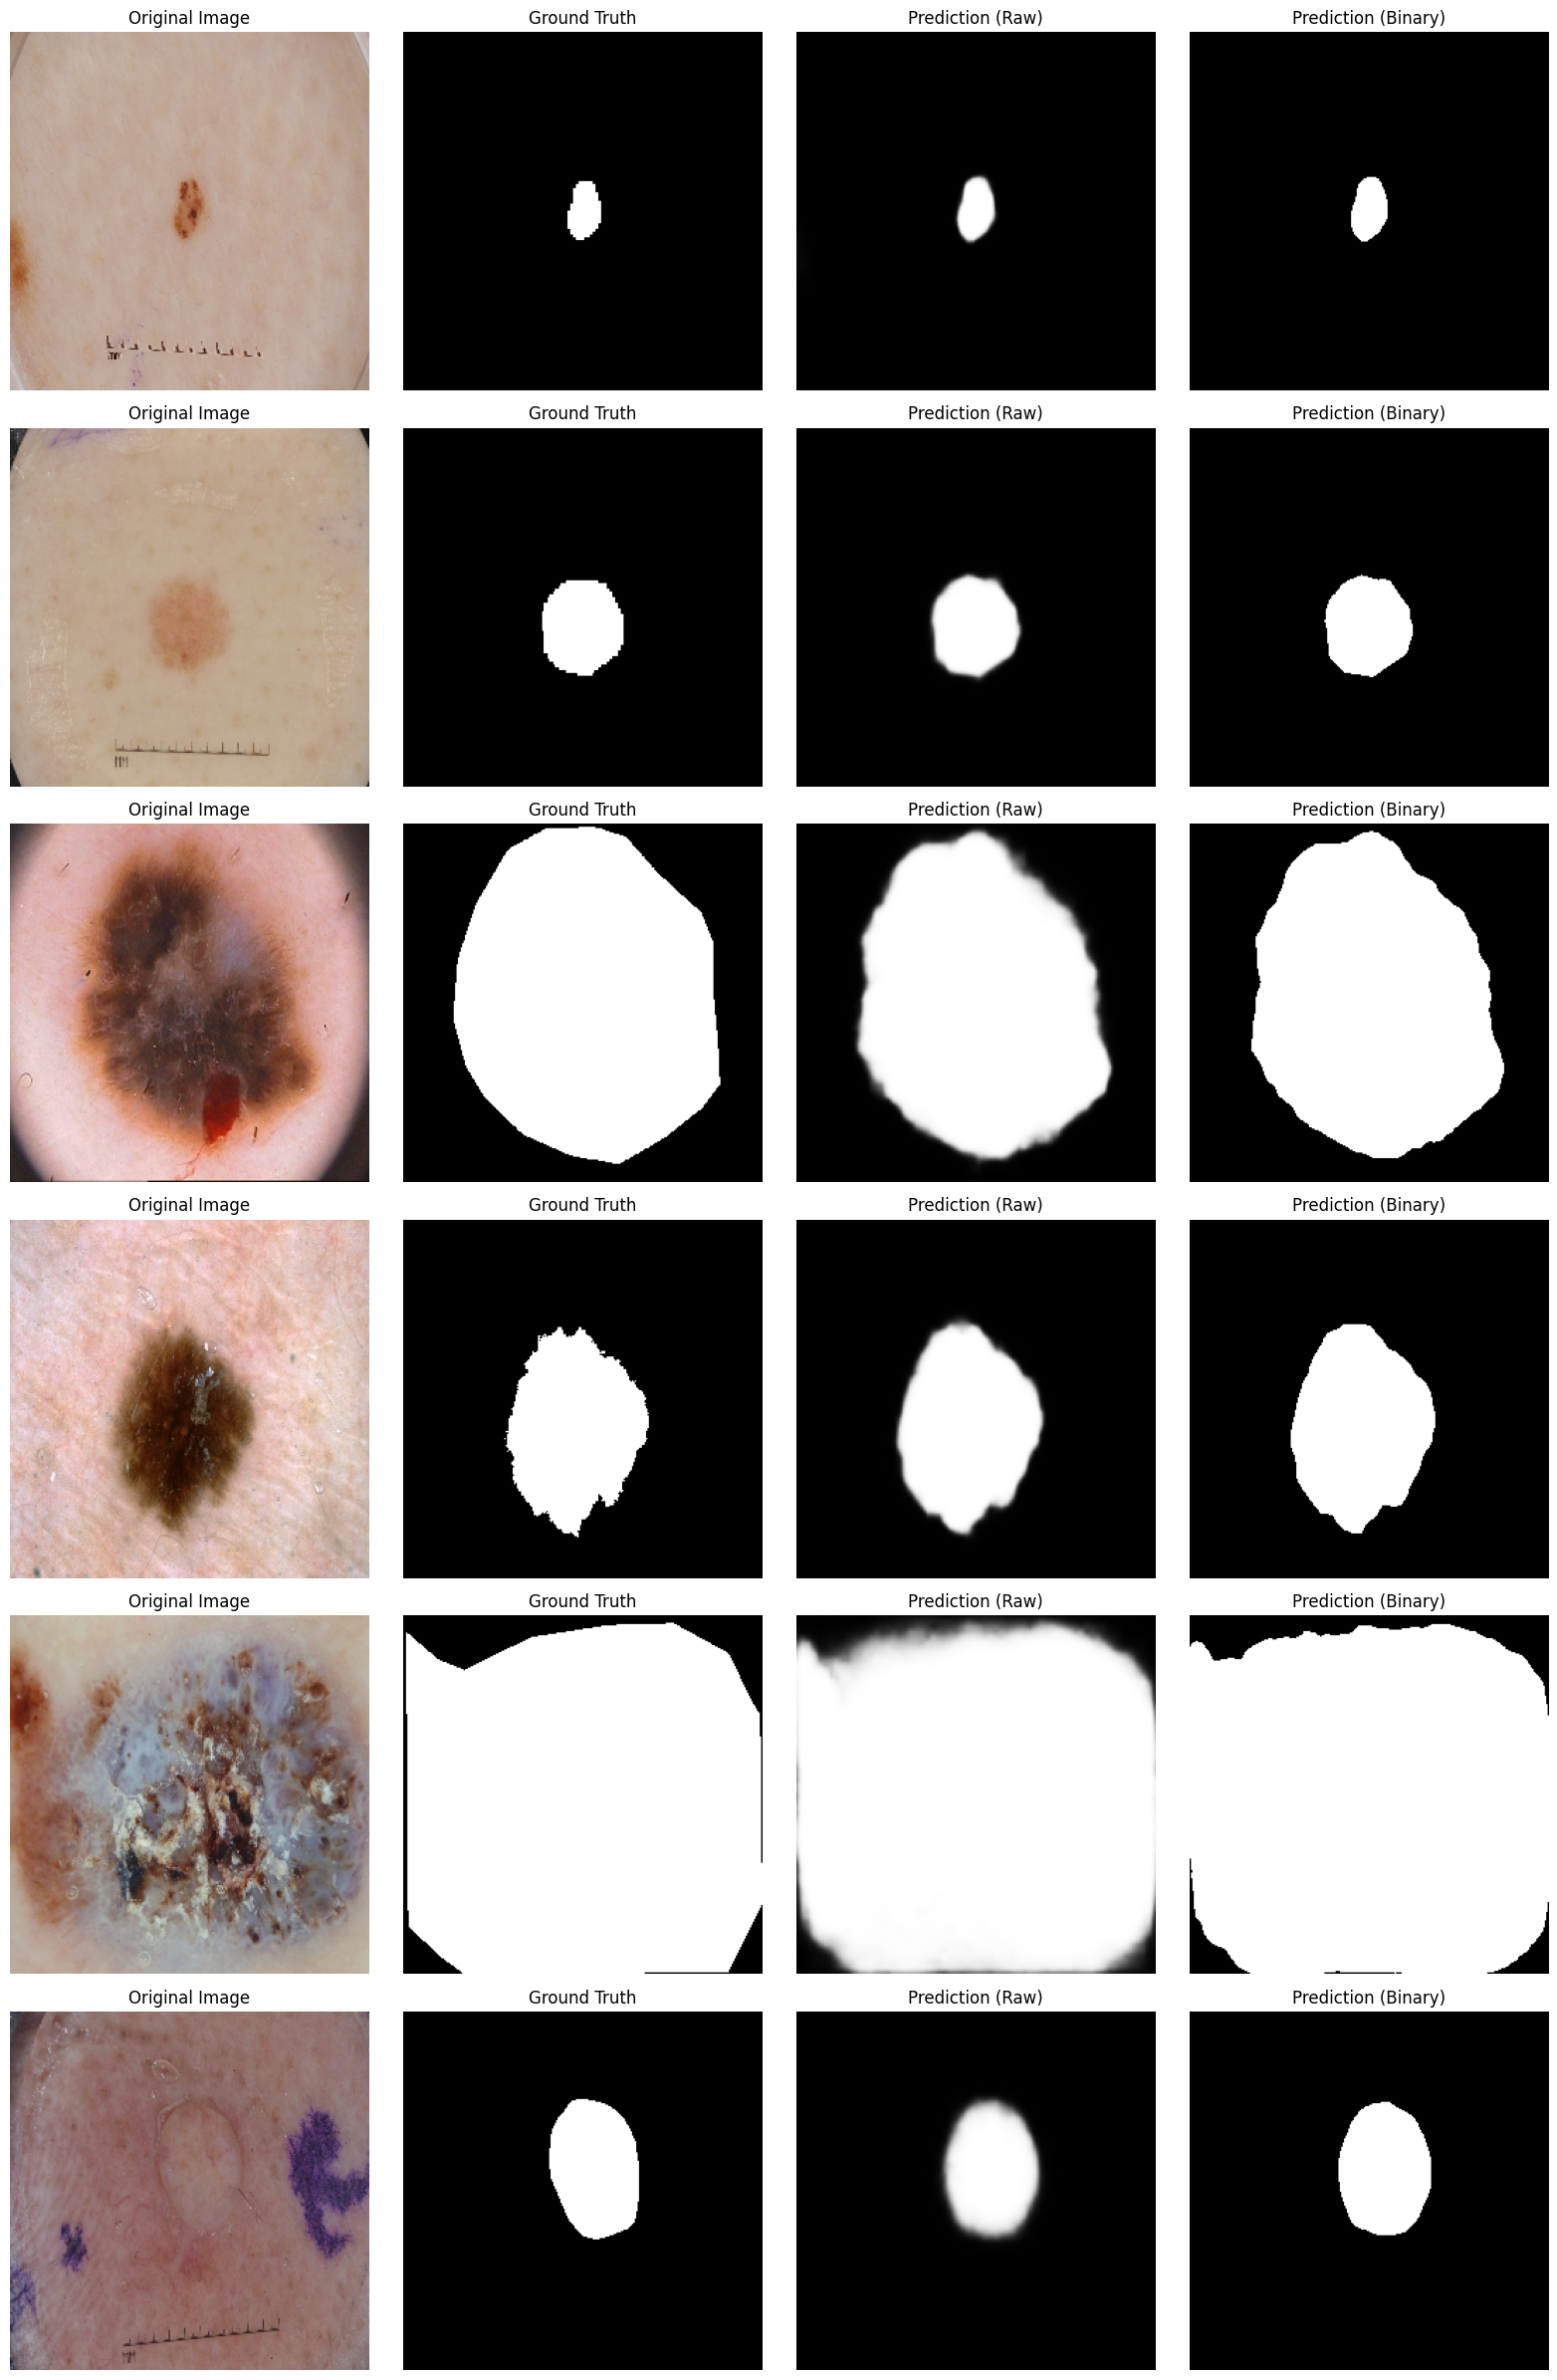

✅ Visualization saved (FIX BUG #22 - proper denormalization)


In [13]:
# ==============================================================================
# Ô CODE 11: VISUALIZE PREDICTIONS (FIX BUG #22)
# ==============================================================================

def visualize_predictions(model, dataset, device, num_samples=6):
    """
    ✅ FIX BUG #22: Denormalization MATCH normalization
    """
    model.eval()
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

    indices = np.random.choice(len(dataset), num_samples, replace=False)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]

            pred = model(image.unsqueeze(0).to(device))
            pred = torch.sigmoid(pred).squeeze().cpu().numpy()

            # ✅ FIX BUG #22: DENORMALIZE MATCH NORMALIZATION CONFIG
            img_display = image.permute(1, 2, 0).numpy()
            img_display = NormalizationConfig.denormalize(img_display)

            mask_display = mask.squeeze().numpy()
            pred_binary = (pred > 0.5).astype(np.float32)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title('Original Image')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(mask_display, cmap='gray')
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(pred, cmap='gray')
            axes[i, 2].set_title('Prediction (Raw)')
            axes[i, 2].axis('off')

            axes[i, 3].imshow(pred_binary, cmap='gray')
            axes[i, 3].set_title('Prediction (Binary)')
            axes[i, 3].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_PATH, 'predictions.png'), dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(model, test_dataset, device, num_samples=6)
print(f"✅ Visualization saved (FIX BUG #22 - proper denormalization)")

In [14]:
# ==============================================================================
# Ô CODE 12: SAVE FINAL CHECKPOINT (FIX BUG #23, #26)
# ==============================================================================

print("\n" + "="*80)
print("💾 LƯU FINAL CHECKPOINT (FIX BUG #23, #26)")
print("="*80)

final_checkpoint = {
    "step": "03_deeplabv3plus_training",
    "status": "completed",
    "timestamp": pd.Timestamp.now().isoformat(),
    "version": "1.0",

    # ============================================================
    # ✅ FIX BUG #23, #26: MODEL INFO
    # ============================================================
    "model": {
        "architecture": "DeepLabV3+",
        "encoder": "ResNet50",
        "encoder_weights": "imagenet",
        "in_channels": 3,
        "out_channels": 1,
        "activation": "Sigmoid (binary segmentation)",
        "note": "More advanced than U-Net - has ASPP (Atrous Spatial Pyramid Pooling)"
    },

    # ============================================================
    # ✅ FIX BUG #23, #26: DATA PREPROCESSING CONFIG
    # ============================================================
    "preprocessing": {
        "image_size": (256, 256),
        "normalization": {
            "method": "Global (FIX BUG #19)",
            "mean": NormalizationConfig.MEAN.tolist(),
            "std": NormalizationConfig.STD.tolist(),
            "note": "MATCH File 02 for ensemble consistency"
        },
        "augmentation": {
            "training": True,
            "transforms": [
                "HorizontalFlip (p=0.5)",
                "VerticalFlip (p=0.3)",
                "Rotate (limit=30, p=0.5)",
                "RandomBrightnessContrast (p=0.5)",
                "CoarseDropout (p=0.2)"
            ],
            "note": "FIX BUG #20 - GaussNoise removed (no mask support)"
        },
        "validation_augmentation": False,
        "interpolation": "INTER_NEAREST for mask resize"
    },

    # ============================================================
    # ✅ FIX BUG #24: TRAINING CONFIG (BATCH SIZE)
    # ============================================================
    "training": {
        "batch_size": int(BATCH_SIZE),
        "batch_size_note": "FIX BUG #24 - MATCH File 02 (U-Net) for ensemble",
        "num_epochs_planned": NUM_EPOCHS,
        "num_epochs_trained": len(history['train_loss']),
        "early_stopping": {
            "patience": EARLY_STOPPING_PATIENCE,
            "early_stopped": bool(early_stopped),
            "patience_final": int(patience_counter)
        },
        "optimizer": "Adam",
        "learning_rate": 1e-4,
        "scheduler": "ReduceLROnPlateau (factor=0.5, patience=5)",
        "loss": "Dice(0.6) + BCE(0.4)",
        "metrics": ["IoU", "Dice"]
    },

    # ============================================================
    # ✅ FIX BUG #25: DATA SOURCE & IMBALANCE REFERENCE
    # ============================================================
    "data": {
        "segmentation_path": SEG_DATA_PATH,
        "train_samples": len(train_dataset),
        "val_samples": len(val_dataset),
        "test_samples": len(test_dataset),
        "prepared_by_checkpoint": "01_prepare_and_split_complete.json",
        "imbalance_severity_reference": imbalance_analysis.get('severity', 'UNKNOWN'),
        "imbalance_ratio_reference": float(imbalance_analysis.get('imbalance_ratio', 1.0)),
        "note": "Segmentation handles both balanced & imbalanced data"
    },

    # ============================================================
    # ✅ FIX BUG #23, #26: TRAINING RESULTS
    # ============================================================
    "results": {
        "best_epoch": history['val_dice'].index(max(history['val_dice'])) + 1 if len(history['val_dice']) > 0 else 0,
        "best_val_dice": float(best_val_dice),
        "best_val_iou": float(history['val_iou'][history['val_dice'].index(max(history['val_dice']))] if len(history['val_dice']) > 0 else 0),
        "test_dice": float(test_dice),
        "test_iou": float(test_iou),
        "test_loss": float(test_loss)
    },

    # ============================================================
    # ✅ FIX BUG #23, #26: BUGS FIXED IN THIS FILE
    # ============================================================
    "bugs_fixed": {
        "BUG_19": "Normalization: ImageNet → Global (medical-safe)",
        "BUG_20": "Augmentation: GaussNoise → CoarseDropout (mask compatible)",
        "BUG_21": "Early stopping: Fixed duplicate logic, proper resume",
        "BUG_22": "Denormalization: Use NormalizationConfig.denormalize()",
        "BUG_23": "Checkpoint: Add comprehensive metadata",
        "BUG_24": "Batch size: MATCH File 02 (8, not 16) for ensemble",
        "BUG_25": "Imbalance reference: Load from File 01 checkpoint",
        "BUG_26": "Checkpoint detail: Add augmentation, batch size, imbalance ref"
    },

    # ============================================================
    # ✅ FIX BUG #23, #26: COMPARISON WITH FILE 02 (U-NET)
    # ============================================================
    "comparison_with_unet": {
        "architecture": "DeepLabV3+ (more advanced) vs U-Net (simpler)",
        "encoder": "ResNet50 (stronger) vs ResNet34",
        "batch_size": "8 (MATCHED)",
        "normalization": "Global [0.5]/[0.25] (MATCHED)",
        "augmentation": "Same transforms (MATCHED)",
        "expected_performance": "DeepLabV3+ may achieve higher Dice than U-Net",
        "ensemble_strategy": "Both will be compared in File 04"
    },

    # ============================================================
    # ✅ FIX BUG #23, #26: FILE DEPENDENCIES
    # ============================================================
    "file_dependencies": {
        "input": [
            "File 01 (segmentation split data)",
            "File 01 (imbalance_analysis reference)"
        ],
        "output_used_by": [
            "File 04 (Ensemble - compare U-Net vs DeepLab)",
            "File 05 (ROI extraction - use best model from File 04)",
            "File 06 (Classification - same normalization)"
        ]
    },

    # ============================================================
    # ✅ FIX BUG #23, #26: PATHS
    # ============================================================
    "paths": {
        "best_model": BEST_MODEL_PATH,
        "last_checkpoint": LAST_CHECKPOINT_PATH,
        "history_csv": HISTORY_CSV_PATH,
        "training_history_plot": os.path.join(MODEL_SAVE_PATH, 'training_history.png'),
        "predictions_visualization": os.path.join(MODEL_SAVE_PATH, 'predictions.png')
    },

    # ============================================================
    # ✅ FIX BUG #23, #26: CLINICAL NOTES
    # ============================================================
    "clinical_notes": {
        "use_case": "Medical image segmentation of skin lesions",
        "output": "Binary segmentation mask (lesion boundaries)",
        "validation": "Test Dice = {:.4f}, Test IoU = {:.4f}".format(test_dice, test_iou),
        "recommendation": "Advanced model for automated lesion boundary detection"
    }
}

checkpoint_file = os.path.join(CHECKPOINT_PATH, "03_deeplabv3plus_complete.json")
with open(checkpoint_file, 'w') as f:
    json.dump(final_checkpoint, f, indent=4)

print(f"✅ Checkpoint saved: {checkpoint_file}")
print(f"   📊 Comprehensive metadata included (FIX BUG #23, #26)")
print(f"   🔗 Traceable from File 01 to File 04")
print(f"   ⚖️ Fair comparison with File 02 (batch size, normalization matched)")
print(f"\n✅ Best model: {BEST_MODEL_PATH}")
print(f"✅ Last checkpoint: {LAST_CHECKPOINT_PATH}")
print(f"✅ Training history CSV: {HISTORY_CSV_PATH}")

print(f"\n💡 Để resume training: Chỉ cần chạy lại từ Ô CODE 8")
print(f"\n🎉 HOÀN THÀNH BƯỚC 3: HUẤN LUYỆN DEEPLABV3+ (ALL BUGS FIXED)!")


💾 LƯU FINAL CHECKPOINT (FIX BUG #23, #26)
✅ Checkpoint saved: d:/DoAn_DaLieu/3_Checkpoints/03_deeplabv3plus_complete.json
   📊 Comprehensive metadata included (FIX BUG #23, #26)
   🔗 Traceable from File 01 to File 04
   ⚖️ Fair comparison with File 02 (batch size, normalization matched)

✅ Best model: d:/DoAn_DaLieu/4_Models/deeplabv3plus/deeplabv3plus_best.pth
✅ Last checkpoint: d:/DoAn_DaLieu/4_Models/deeplabv3plus/deeplabv3plus_last.pth
✅ Training history CSV: d:/DoAn_DaLieu/4_Models/deeplabv3plus/training_history.csv

💡 Để resume training: Chỉ cần chạy lại từ Ô CODE 8

🎉 HOÀN THÀNH BƯỚC 3: HUẤN LUYỆN DEEPLABV3+ (ALL BUGS FIXED)!
